# PCG - Estudo de Caso Duke Breast Cancer

Bem-vindo ao roteiro da Pesquisa Curricularizada de Graduação (PCG). Este notebook tem como objetivo realizar uma Análise Exploratória de Dados (EDA) do conjunto de dados "Duke Breast Cancer". 

Nossa missão é avaliar características demográficas, clínicas e moleculares para compreender os padrões da doença e identificar fatores preditivos de resposta ao tratamento neoadjuvante, utilizando técnicas de estatística descritiva e storytelling com dados.

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuração visual para os gráficos
sns.set_theme(style='whitegrid')

# Ingestão de dados
# O parâmetro na_values força o Pandas a reconhecer os textos do dataset como valores ausentes reais (NaN)
valores_ausentes = ['NA', 'NC', 'NP', 'x', '']

df_breast_cancer = pd.read_csv(
    './Dataset/Clinical_and_Other_Features.csv', 
    sep=';', 
    header=1, 
    low_memory=False, 
    na_values=valores_ausentes
)

## 4. Inconsistências e Qualidade dos Dados

A qualidade dos dados é crucial na investigação clínica. Primeiramente, iremos quantificar os dados ausentes. Para preservar o perfil real das pacientes e não introduzir viés com imputações artificiais (como o preenchimento por médias em variáveis biológicas), a nossa estratégia será remover as linhas que possuam falhas críticas nas colunas fundamentais para este estudo. 

Em seguida, aplicaremos engenharia de atributos para converter a idade das pacientes de dias para anos.

In [5]:
# Relatório de valores nulos (Top 10 em percentual)
null_report = (df_breast_cancer.isnull().sum() / len(df_breast_cancer)) * 100
print("--- TOP 10 COLUNAS COM DADOS AUSENTES (%) ---")
print(null_report.sort_values(ascending=False).head(10))
print("\n")

# Engenharia de Atributos: Forçar a conversão para numérico antes de calcular a idade
df_breast_cancer['Date of Birth (Days)'] = pd.to_numeric(df_breast_cancer['Date of Birth (Days)'], errors='coerce')
df_breast_cancer['Age_Years'] = df_breast_cancer['Date of Birth (Days)'].abs() / 365.25

# Lista das colunas críticas com os nomes exatos do dataset
critical_columns = [
    'Age_Years',
    'Staging(Tumor Size)# [T]',
    'Staging(Nodes)#(Nx replaced by -1)[N]',
    'Mol Subtype',
    'Overall Near-complete Response:  Stricter Definition'
]

# Remoção de nulos estritamente para o escopo da pesquisa
df_breast_cancer.dropna(subset=critical_columns, inplace=True)

# Padronizar as colunas de estadiamento clínico como texto limpo.
# Isso evita que as Células 6 e 8 quebrem ao tentar ordenar os eixos dos gráficos.
df_breast_cancer['Staging(Tumor Size)# [T]'] = df_breast_cancer['Staging(Tumor Size)# [T]'].astype(str).str.replace('.0', '', regex=False)
df_breast_cancer['Staging(Nodes)#(Nx replaced by -1)[N]'] = df_breast_cancer['Staging(Nodes)#(Nx replaced by -1)[N]'].astype(str).str.replace('.0', '', regex=False)

--- TOP 10 COLUNAS COM DADOS AUSENTES (%) ---
Unnamed: 98                                               100.000000
Unnamed: 67                                               100.000000
Unnamed: 42                                                99.674973
Unnamed: 46                                                99.674973
Unnamed: 45                                                99.674973
Unnamed: 44                                                99.674973
Unnamed: 47                                                99.674973
Solid                                                      98.483207
Days to local recurrence (from the date of diagnosis)      98.266522
Mass Density                                               98.158180
dtype: float64




## 1. Contexto Geral (O Panorama da Doença)

Compreender a distribuição etária das pacientes é o primeiro passo biológico. Iremos analisar como a idade se distribui neste conjunto de dados e de que forma esta se correlaciona com a gravidade do câncer (estágio do tumor) no momento do diagnóstico. 

* A assimetria no histograma nos indicará a faixa etária predominante.
* O boxplot revelará se pacientes de diferentes idades tendem a apresentar tumores iniciais maiores ou menores.

--- ESTATÍSTICA DESCRITIVA DA IDADE ---
mean    49.528538
50%     48.095825
std     11.388697
Name: Age_Years, dtype: float64


C:\Users\gumsb\AppData\Local\Temp\ipykernel_3560\1998876032.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_breast_cancer, x='Staging(Tumor Size)# [T]', y='Age_Years', order=stage_t_order, palette='Set2', ax=axes[1])


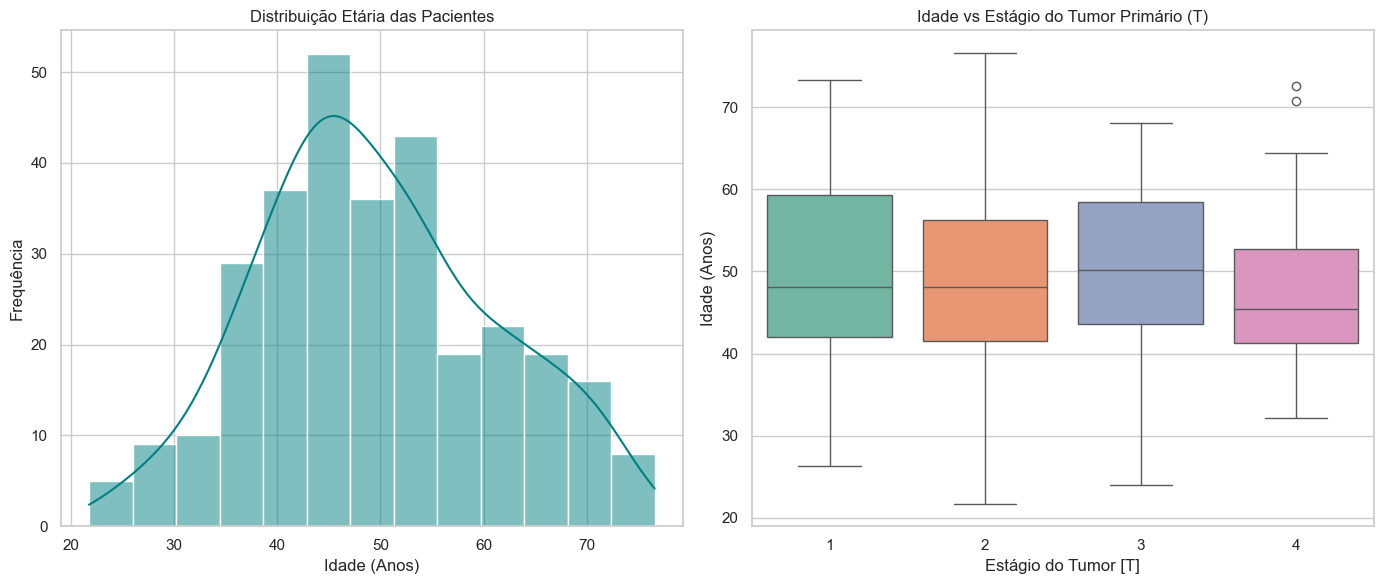

In [6]:
# Estatística descritiva básica da idade
print("--- ESTATÍSTICA DESCRITIVA DA IDADE ---")
print(df_breast_cancer['Age_Years'].describe()[['mean', '50%', 'std']])

# Criação dos subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Histograma da Idade
sns.histplot(data=df_breast_cancer, x='Age_Years', kde=True, color='teal', ax=axes[0])
axes[0].set_title('Distribuição Etária das Pacientes')
axes[0].set_xlabel('Idade (Anos)')
axes[0].set_ylabel('Frequência')

# Boxplot cruzando Estágio do Tumor (T) com Idade
stage_t_order = sorted(df_breast_cancer['Staging(Tumor Size)# [T]'].unique())
sns.boxplot(data=df_breast_cancer, x='Staging(Tumor Size)# [T]', y='Age_Years', order=stage_t_order, palette='Set2', ax=axes[1])
axes[1].set_title('Idade vs Estágio do Tumor Primário (T)')
axes[1].set_xlabel('Estágio do Tumor [T]')
axes[1].set_ylabel('Idade (Anos)')

plt.tight_layout()
plt.show()

## 2. Identificação de Padrões (As Características Clínicas)

A progressão tumoral segue frequentemente um padrão de invasão local seguido de disseminação regional. 

Neste bloco, investigamos a correlação entre o tamanho físico do tumor primário (T) e o comprometimento dos linfonodos axilares (N). O gráfico de violino nos ajudará a avaliar visualmente se tumores maiores aumentam a probabilidade de disseminação linfática.

C:\Users\gumsb\AppData\Local\Temp\ipykernel_3560\1977131933.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


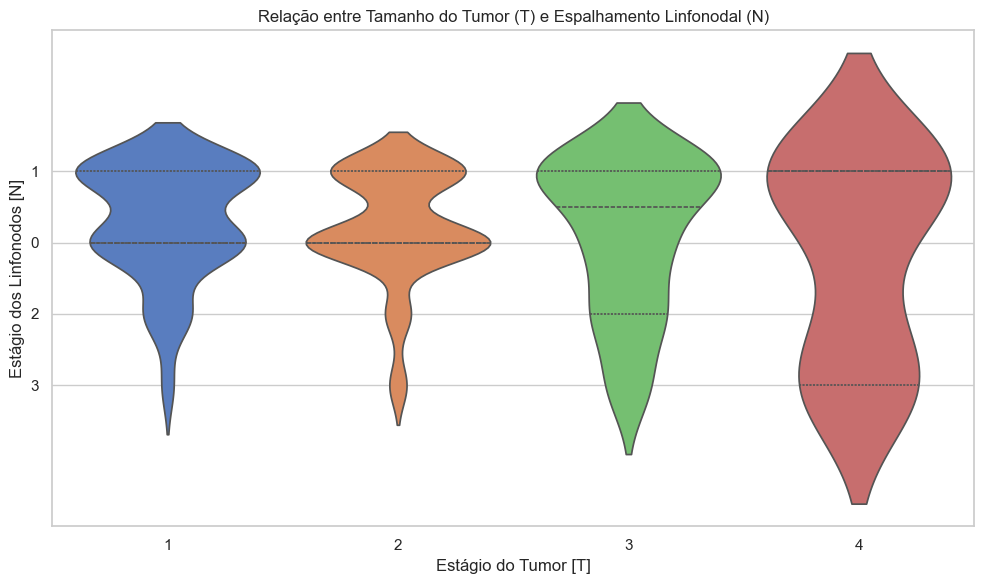

In [7]:
fig = plt.figure(figsize=(10, 6))

# Tratamento numérico temporal para N-Staging para ordenar visualmente
node_order = sorted(df_breast_cancer['Staging(Nodes)#(Nx replaced by -1)[N]'].unique())

sns.violinplot(
    data=df_breast_cancer, 
    x='Staging(Tumor Size)# [T]', 
    y='Staging(Nodes)#(Nx replaced by -1)[N]', 
    order=stage_t_order, 
    inner='quartile', 
    palette='muted'
)

plt.title('Relação entre Tamanho do Tumor (T) e Espalhamento Linfonodal (N)')
plt.xlabel('Estágio do Tumor [T]')
plt.ylabel('Estágio dos Linfonodos [N]')
plt.tight_layout()
plt.show()

## 3. Análise de Subgrupos (Os Tipos de Câncer)

O câncer de mama não é uma doença única. Ele é caracterizado por sua heterogeneidade molecular, impulsionada pela presença ou ausência de receptores hormonais (ER, PR, HER2). 

Esta análise agrupa as pacientes nestes subtipos biológicos para compreendermos o volume e o perfil de cada classificação na nossa amostra, servindo de base para a predição terapêutica que faremos a seguir.

C:\Users\gumsb\AppData\Local\Temp\ipykernel_3560\188135545.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=subtype_distribution.values, y=subtype_distribution.index, palette='magma')


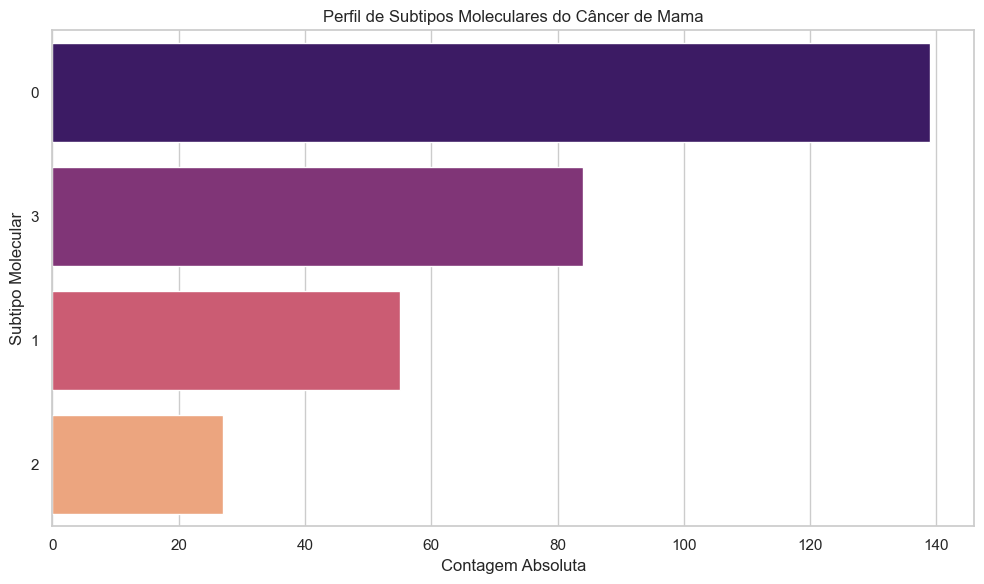

In [8]:
subtype_distribution = df_breast_cancer['Mol Subtype'].value_counts()

fig = plt.figure(figsize=(10, 6))
sns.barplot(x=subtype_distribution.values, y=subtype_distribution.index, palette='magma')

plt.title('Perfil de Subtipos Moleculares do Câncer de Mama')
plt.xlabel('Contagem Absoluta')
plt.ylabel('Subtipo Molecular')
plt.tight_layout()
plt.show()

## 5. O Desfecho (O Insight Estratégico)

Para avaliar a eficácia terapêutica, utilizaremos a definição rigorosa de "Resposta Quase Completa" (*Stricter Definition*), que reflete a Resposta Patológica Completa (pCR) — o padrão-ouro na literatura médica para a avaliação de tratamentos neoadjuvantes (antes da cirurgia). 

Vamos cruzar o subtipo molecular e a idade da paciente com este desfecho para desenhar o perfil clínico com maior probabilidade de sucesso face à intervenção médica.

C:\Users\gumsb\AppData\Local\Temp\ipykernel_3560\2685598071.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_breast_cancer, x=target_response_col, y='Age_Years', palette='pastel', ax=axes[1])


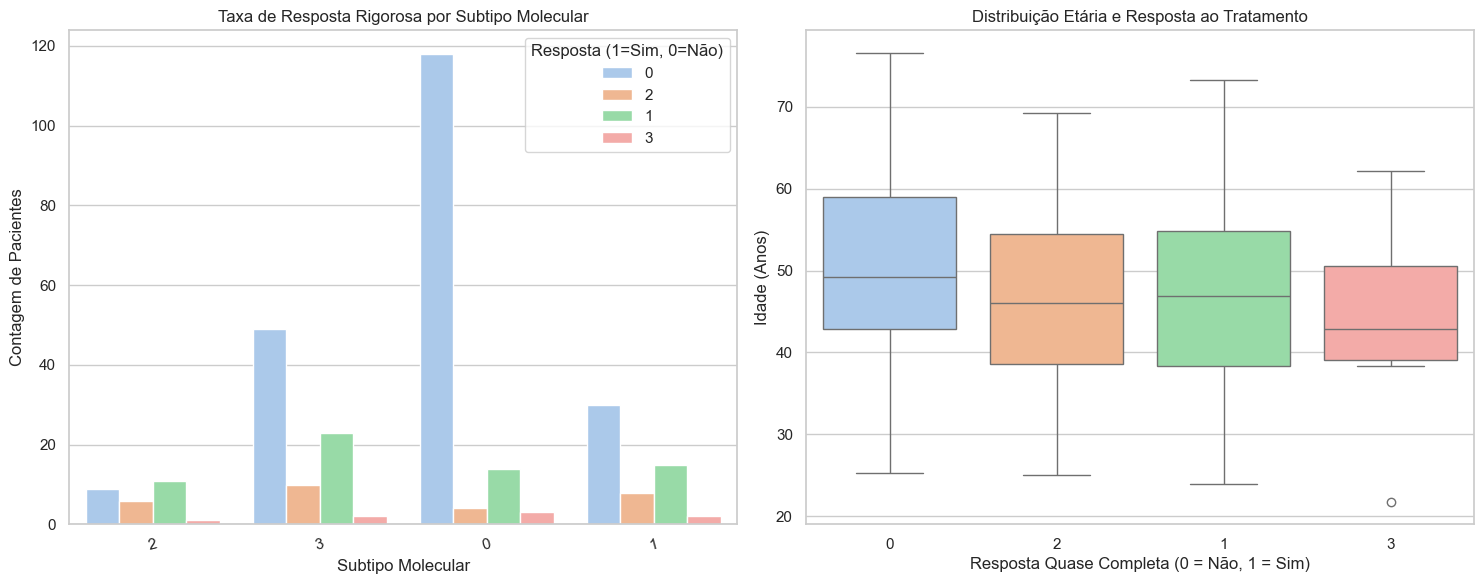

In [10]:
target_response_col = 'Overall Near-complete Response:  Stricter Definition'

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Countplot para Subtipos vs Resposta
sns.countplot(data=df_breast_cancer, x='Mol Subtype', hue=target_response_col, palette='pastel', ax=axes[0])
axes[0].set_title('Taxa de Resposta Rigorosa por Subtipo Molecular')
axes[0].set_xlabel('Subtipo Molecular')
axes[0].set_ylabel('Contagem de Pacientes')
axes[0].tick_params(axis='x', rotation=15)
axes[0].legend(title='Resposta (1=Sim, 0=Não)')

# Boxplot para Resposta vs Idade
sns.boxplot(data=df_breast_cancer, x=target_response_col, y='Age_Years', palette='pastel', ax=axes[1])
axes[1].set_title('Distribuição Etária e Resposta ao Tratamento')
axes[1].set_xlabel('Resposta Quase Completa (0 = Não, 1 = Sim)')
axes[1].set_ylabel('Idade (Anos)')

plt.tight_layout()
plt.show()

## Conclusão da Apresentação

O cruzamento da idade, dos subtipos moleculares e do tamanho inicial do tumor nos permite construir um perfil preditivo robusto. 

Através deste Storytelling de dados, observamos historicamente como as características iniciais de diagnóstico afetam de maneira drástica as taxas de resposta às terapias sistêmicas. Estas visualizações fornecem uma fundação baseada em dados reais para apoiar decisões oncológicas estratégicas e validar as hipóteses biológicas da nossa pesquisa.